In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
simulaciones = pd.read_json("simulation.jsonlines", lines=True)
planes = pd.read_json("plans.jsonlines", lines=True)

# Analizando las simulaciones

In [2]:
simulaciones

,eventDescription,eventTime,eventType,simulationId,truckId
0,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5760,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1669HSZ
1,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5730,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,8809GPH
2,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5730,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1161GJN
3,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5430,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,3321FBL
4,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5310,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,2423VRT
...,...,...,...,...,...
26577,"(calle de Juan de Austria, 1, Madrid, [-3.6991...",11562780,Truck arrived,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB
26578,"Packet 83 to (calle de Juan de Austria, 1, Mad...",11623380,Truck ended delivering,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB
26579,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",11623470,Truck departed to depot,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB
26580,,11813550,Truck ended route,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB


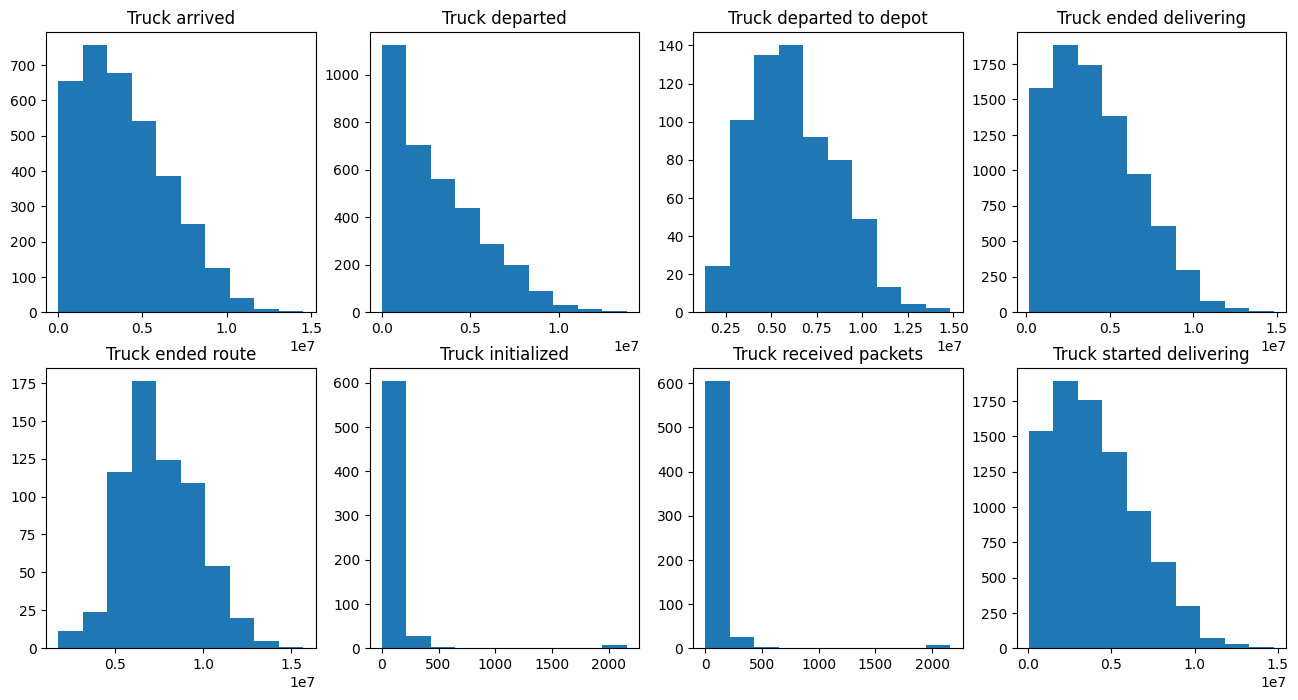

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (i, lista) in zip(axes,simulaciones.groupby("eventType").eventTime.agg(list).items()): #Ver como se distribuyen los tiempos para cada tipo de evento
    ax.hist(lista)
    ax.set_title(i)

In [4]:
simulaciones.groupby("eventType").eventTime.describe() #Ver estadísticas de cada tipo de evento

,count,mean,std,min,25%,50%,75%,max
eventType,,,,,,,,
Truck arrived,3444.0,3.972448e+06,2.569578e+06,30390.0,1874955.0,3596520.0,5648617.5,14530650.0
Truck departed,3444.0,3.040994e+06,2.601769e+06,360.0,918802.5,2548395.0,4676280.0,13838100.0
Truck departed to depot,640.0,6.232325e+06,2.332695e+06,1378410.0,4431705.0,5952045.0,7906027.5,14833350.0
Truck ended delivering,8567.0,4.147040e+06,2.558345e+06,150990.0,2055330.0,3779940.0,5826135.0,14833050.0
Truck ended route,640.0,7.535140e+06,2.157122e+06,1768530.0,5994165.0,7287840.0,9032520.0,15683250.0
Truck initialized,640.0,1.012969e+02,2.281717e+02,0.0,30.0,60.0,90.0,2160.0
Truck received packets,640.0,9.539062e+01,2.256020e+02,0.0,30.0,60.0,90.0,2160.0
Truck started delivering,8567.0,4.056088e+06,2.558056e+06,30390.0,1965825.0,3690420.0,5736705.0,14772420.0


In [5]:
lista_a_cambiar = ["Truck arrived","Truck departed","Truck departed to depot","Truck ended delivering","Truck ended route","Truck started delivering"]

In [6]:
simulaciones = simulaciones.join(simulaciones[simulaciones.eventType.isin(lista_a_cambiar)].eventTime.apply(lambda x: x/1000 if x>7*1e04 else x), rsuffix="_seg")
simulaciones["eventTime_seg"] = simulaciones.eventTime_seg.fillna(simulaciones["eventTime"])

In [7]:
simulaciones.groupby("eventType").eventTime_seg.describe()

,count,mean,std,min,25%,50%,75%,max
eventType,,,,,,,,
Truck arrived,3444.0,3991.044364,2655.763793,71.16,1880.7825,3603.405,5651.0775,33720.00
Truck departed,3444.0,3285.513876,2374.882101,155.73,1350.0000,2611.830,4697.6625,13838.10
Truck departed to depot,640.0,6232.325484,2332.695379,1378.41,4431.7050,5952.045,7906.0275,14833.35
Truck ended delivering,8567.0,4147.039855,2558.344796,150.99,2055.3300,3779.940,5826.1350,14833.05
Truck ended route,640.0,7535.140219,2157.121999,1768.53,5994.1650,7287.840,9032.5200,15683.25
Truck initialized,640.0,101.296875,228.171694,0.00,30.0000,60.000,90.0000,2160.00
Truck received packets,640.0,95.390625,225.601968,0.00,30.0000,60.000,90.0000,2160.00
Truck started delivering,8567.0,4063.567679,2593.011091,71.16,1968.6450,3694.320,5740.2600,33750.00


In [8]:
simulaciones = simulaciones.drop("eventTime", axis=1)

In [9]:
simulaciones

,eventDescription,eventType,simulationId,truckId,eventTime_seg
0,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1669HSZ,5760.00
1,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,8809GPH,5730.00
2,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1161GJN,5730.00
3,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,3321FBL,5430.00
4,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,2423VRT,5310.00
...,...,...,...,...,...
26577,"(calle de Juan de Austria, 1, Madrid, [-3.6991...",Truck arrived,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11562.78
26578,"Packet 83 to (calle de Juan de Austria, 1, Mad...",Truck ended delivering,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11623.38
26579,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed to depot,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11623.47
26580,,Truck ended route,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11813.55


# Analizando los planes

In [10]:
planes

,items,simulationId,trucks
0,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',..."
1,"[{'itemId': '0', 'locationId': '271c4e156a04e8...",a8a11526-6b9b-4143-bfb1-ffcae600a17e,"[{'items': ['62', '63', '69', '70', '71', '21'..."
2,"[{'itemId': '0', 'locationId': '6aa95e84c67637...",2f956e3a-25df-4c5e-bb50-92d92dc9ba00,"[{'items': ['79', '20', '21', '5', '76', '59',..."
3,"[{'itemId': '0', 'locationId': '0078f3bf6db092...",45c9a42a-7cb5-4266-b0aa-a05b3f446390,"[{'items': ['3', '4', '5', '6', '72', '11', '1..."
4,"[{'itemId': '0', 'locationId': '92e059821c9ca8...",864bd9f3-074d-45e8-a032-5a01237ae290,"[{'items': ['77', '78', '79', '16', '17', '91'..."
...,...,...,...
94,"[{'itemId': '0', 'locationId': '281ec8ac82cccd...",81acb266-ab82-497b-92d9-fae490cc4823,"[{'items': ['36', '37', '49', '6', '7', '8', '..."
95,"[{'itemId': '0', 'locationId': '950001b613cb58...",f007019f-866d-48be-a0cb-bd96328ee43b,"[{'items': ['46', '47', '48', '49', '40', '24'..."
96,"[{'itemId': '0', 'locationId': 'b40599012e4fba...",f0f90050-5a0f-4965-864e-d6bc0d02b5a0,"[{'items': ['16', '17', '42', '43', '44', '45'..."
97,"[{'itemId': '0', 'locationId': '074dc13529fd8b...",e33505ca-bfdb-496f-bcfd-b8b913a42637,"[{'items': ['62', '63', '64', '86', '10', '11'..."


In [11]:
planes = planes.join(planes.trucks.explode().apply(pd.Series), lsuffix='_sim').reset_index(drop=True)
planes

,items_sim,simulationId,trucks,items,route,truck_id
0,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH
1,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[74, 75, 76, 67, 68, 69, 70, 92, 93, 94, 55, 5...","[{'destination': 'faf06210580833f8c7963506', '...",2423VRT
2,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[18, 19, 57, 58, 88, 89, 90, 91, 54, 20, 21, 2...","[{'destination': 'bef2df0471ee1c26b4ab6ba9', '...",0265TYL
3,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[87, 0, 1, 2, 3, 33, 95, 96, 97]","[{'destination': '7a249403ad22a72495769f75', '...",8809GPH
4,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[31, 32, 37, 38, 39, 66]","[{'destination': '1e38734ff239ccf75bf04b95', '...",1161GJN
...,...,...,...,...,...,...
635,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[53, 54, 55, 83, 84, 85, 86, 26, 27, 29, 30, 3...","[{'destination': '225cd814768e8ca390983313', '...",5534TPH
636,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[72, 73, 74, 88, 89, 90, 91, 43, 62, 63, 64, 3...","[{'destination': '417bf3aae83127cd905f3bc9', '...",3953RLD
637,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[6, 7, 8, 9]","[{'destination': '1e1251e186dd507f63e4d1e6', '...",5030LXK
638,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[44, 45, 46, 47, 94, 20, 21, 22, 95, 96, 97, 6...","[{'destination': '6a33d0bcd3624ccb86febf09', '...",3321FBL


In [12]:
planes = planes.join(planes.route.explode().apply(pd.Series), lsuffix='_sim').reset_index(drop=True)
planes

,items_sim,simulationId,trucks,items,route,truck_id,destination,duration,origin
0,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,af3ea5c0e98151a51bd39c64,197,ce6feed06bc1a9e5aff95f04
1,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,c0430d1e19c34a06e343a270,733,af3ea5c0e98151a51bd39c64
2,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,b31f6bb5c55435cb5495a62b,380,c0430d1e19c34a06e343a270
3,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,58a50ddf91095c052e330fd6,612,b31f6bb5c55435cb5495a62b
4,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,910cd4ad38bc68ff7abdd941,850,58a50ddf91095c052e330fd6
...,...,...,...,...,...,...,...,...,...
4079,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,5bec37aee4796cc965e71c88,1173,20ee036e147b4a1bd5af0e1c
4080,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,1f183bd64aa5bfae47843de5,1198,5bec37aee4796cc965e71c88
4081,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,4551fdc303a5ddafa1dcf28c,1133,1f183bd64aa5bfae47843de5
4082,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,2884f6b369dc20f3051a216d,804,4551fdc303a5ddafa1dcf28c


# Uniendo los dos dataframes

In [13]:
simulaciones.shape

(26582, 5)

In [14]:
planes.shape

(4084, 9)

Los planes son iguales a la suma de "Truck arrive" y "Truck ended route"

In [15]:
simulaciones.groupby("eventType").count()

,eventDescription,simulationId,truckId,eventTime_seg
eventType,,,,
Truck arrived,3444,3444,3444,3444
Truck departed,3444,3444,3444,3444
Truck departed to depot,640,640,640,640
Truck ended delivering,8567,8567,8567,8567
Truck ended route,640,640,640,640
Truck initialized,640,640,640,640
Truck received packets,640,640,640,640
Truck started delivering,8567,8567,8567,8567


In [16]:
simulaciones_viajes = simulaciones[(simulaciones["eventType"].isin(["Truck arrived","Truck initialized"]))].copy()

In [17]:
simulaciones_viajes = simulaciones_viajes.rename(columns={"truckId":"truck_id"})

In [18]:
simulaciones_viajes_sorted = simulaciones_viajes.sort_values(["simulationId","truck_id","eventTime_seg"]).set_index(["simulationId","truck_id"]).copy()

In [19]:
planes_sorted = planes.sort_values(["simulationId","truck_id"]).set_index(["simulationId","truck_id"]).copy()

In [20]:
tiempoViaje = pd.concat([simulaciones_viajes_sorted,planes_sorted], axis=1).copy()

In [21]:
tiempoViaje = tiempoViaje.reset_index()

In [22]:
tiempoViaje.head()

,simulationId,truck_id,eventDescription,eventType,eventTime_seg,items_sim,trucks,items,route,destination,duration,origin
0,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,,Truck initialized,90.00,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",2e8d1b7b9fad4f083892d83c,614,ce6feed06bc1a9e5aff95f04
1,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle del Poeta Blas de Otero, 22, Madrid, [-...",Truck arrived,751.62,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",f5a3aab0c10fb7c5c60f2b01,397,2e8d1b7b9fad4f083892d83c
2,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle de Valdecanillas, 59, Madrid, [-3.62356...",Truck arrived,1475.52,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",4b5f692a806a39d1317d15d4,259,f5a3aab0c10fb7c5c60f2b01
3,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(avda de la Institución Libre de Enseñanza, 19...",Truck arrived,1969.32,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",64bba266de127a5949f52d9a,349,4b5f692a806a39d1317d15d4
4,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(bulev de José Prat, 5, Madrid, [-3.6233859044...",Truck arrived,2508.72,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",6942f2624e971761b7dd9208,384,64bba266de127a5949f52d9a


In [23]:
def tiempo_sim(evento):
    return [j-i for i, j in zip(evento[:-1], evento[1:])]

In [24]:
tiempoViaje["eventTime_entre"]=tiempoViaje.groupby(["simulationId","truck_id"]).eventTime_seg.agg(list).apply(lambda x: tiempo_sim(x)).apply(lambda x: np.append(x,np.nan)).explode().apply(pd.Series).reset_index()[0]

In [25]:
tiempoViaje["eventTime_entre"] = tiempoViaje.eventTime_entre.fillna(tiempoViaje["eventTime_seg"])

In [26]:
tiempoViaje["nItems"] = tiempoViaje["items"].apply(lambda x: len(x))
tiempoViaje["nParadas"] = tiempoViaje["route"].apply(lambda x: len(x))

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
encoderMatriculas = LabelEncoder()
encoderLugar = LabelEncoder()
# encoderDestinos = LabelEncoder()
# encoderOrigenes = LabelEncoder()

In [29]:
tiempoViaje["matriculasCodificadas"] = pd.Series(encoderMatriculas.fit_transform(tiempoViaje.truck_id))

In [30]:
tiempoViaje["destinosCodificados"] = pd.Series(encoderLugar.fit_transform(tiempoViaje.destination))
tiempoViaje["origenesCodificados"] = pd.Series(encoderLugar.fit_transform(tiempoViaje.origin))

In [31]:
"5643c6deb31cabcc68c6045f" in tiempoViaje.destination.unique()

False

In [32]:
def tiempo_acumulado(evento):
    return [np.sum(evento[:i+1]) for i in range(len(evento))]

In [33]:
tiempoViaje["tiempoacumulado_plan"] = tiempoViaje.groupby(["simulationId","truck_id"]).duration.agg(list).apply(lambda x: tiempo_acumulado(x)).explode().apply(pd.Series).reset_index()[0]

In [34]:
tiempoViaje

,simulationId,truck_id,eventDescription,eventType,eventTime_seg,items_sim,trucks,items,route,destination,duration,origin,eventTime_entre,nItems,nParadas,matriculasCodificadas,destinosCodificados,origenesCodificados,tiempoacumulado_plan
0,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,,Truck initialized,90.00,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",2e8d1b7b9fad4f083892d83c,614,ce6feed06bc1a9e5aff95f04,661.62,26,15,9,357,1615,614
1,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle del Poeta Blas de Otero, 22, Madrid, [-...",Truck arrived,751.62,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",f5a3aab0c10fb7c5c60f2b01,397,2e8d1b7b9fad4f083892d83c,723.90,26,15,9,1910,357,1011
2,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle de Valdecanillas, 59, Madrid, [-3.62356...",Truck arrived,1475.52,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",4b5f692a806a39d1317d15d4,259,f5a3aab0c10fb7c5c60f2b01,493.80,26,15,9,596,1910,1270
3,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(avda de la Institución Libre de Enseñanza, 19...",Truck arrived,1969.32,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",64bba266de127a5949f52d9a,349,4b5f692a806a39d1317d15d4,539.40,26,15,9,788,596,1619
4,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(bulev de José Prat, 5, Madrid, [-3.6233859044...",Truck arrived,2508.72,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",6942f2624e971761b7dd9208,384,64bba266de127a5949f52d9a,579.60,26,15,9,828,788,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4079,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle Luis Madrona, S/N, Alcalá de Henares, [...",Truck arrived,2697.81,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",92e059821c9ca8b3967bece4,157,fb28b93228a49e10f73abd62,561.27,17,7,14,1144,1953,2202
4080,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle Marqués de Alonso Martínez, 9, Alcalá d...",Truck arrived,3259.08,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",1f9012c136c055e10f9ef9cb,300,92e059821c9ca8b3967bece4,674.40,17,7,14,230,1144,2502
4081,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle San Vidal, 24, Alcalá de Henares, [-3.3...",Truck arrived,3933.48,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",0efbacc39472a86ca3de1b21,2620,1f9012c136c055e10f9ef9cb,3390.30,17,7,14,101,230,5122
4082,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle de la Comunidad de Madrid, 37, Rozas de...",Truck arrived,7323.78,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",7658997164924eab18ea6e08,472,0efbacc39472a86ca3de1b21,859.20,17,7,14,923,101,5594


In [35]:
"5643c6deb31cabcc68c6045f" in tuple(tiempoViaje.destination + tiempoViaje.origin)

False

In [36]:
len(tuple(tiempoViaje.destination.unique() + tiempoViaje.origin.unique()))

1994

In [37]:
"5643c6deb31cabcc68c6045f" in tiempoViaje.items_sim.explode().apply(lambda x: x["locationId"]).unique()

False

# Predicción tiempo de viaje

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

In [39]:
tiempoViaje.head()

,simulationId,truck_id,eventDescription,eventType,eventTime_seg,items_sim,trucks,items,route,destination,duration,origin,eventTime_entre,nItems,nParadas,matriculasCodificadas,destinosCodificados,origenesCodificados,tiempoacumulado_plan
0,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,,Truck initialized,90.00,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",2e8d1b7b9fad4f083892d83c,614,ce6feed06bc1a9e5aff95f04,661.62,26,15,9,357,1615,614
1,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle del Poeta Blas de Otero, 22, Madrid, [-...",Truck arrived,751.62,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",f5a3aab0c10fb7c5c60f2b01,397,2e8d1b7b9fad4f083892d83c,723.90,26,15,9,1910,357,1011
2,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle de Valdecanillas, 59, Madrid, [-3.62356...",Truck arrived,1475.52,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",4b5f692a806a39d1317d15d4,259,f5a3aab0c10fb7c5c60f2b01,493.80,26,15,9,596,1910,1270
3,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(avda de la Institución Libre de Enseñanza, 19...",Truck arrived,1969.32,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",64bba266de127a5949f52d9a,349,4b5f692a806a39d1317d15d4,539.40,26,15,9,788,596,1619
4,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(bulev de José Prat, 5, Madrid, [-3.6233859044...",Truck arrived,2508.72,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",6942f2624e971761b7dd9208,384,64bba266de127a5949f52d9a,579.60,26,15,9,828,788,2003


In [40]:
# Cargar un dataset de ejemplo
# features = ["duration","eventTime_seg"]
features = ["duration","eventTime_seg","nItems","nParadas","matriculasCodificadas","destinosCodificados","origenesCodificados","tiempoacumulado_plan"]
X, y = tiempoViaje[features], tiempoViaje["eventTime_entre"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Hacer predicciones
y_pred = rf.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 170.4455
R² Score: 0.7805
MSE: 1688142.8602
RMSE: 1299.2855


In [43]:
pd.DataFrame([y_pred, y_test])

,0,1,2,3,4,5,6,7,8,9,...,807,808,809,810,811,812,813,814,815,816
0,7209.389919,1501.331346,1546.073293,1013.64908,1488.138358,9896.127465,1358.268144,923.003573,466.916017,369.292756,...,1087.408308,673.859338,1455.950599,847.63936,932.880668,1009.313813,2938.921667,1042.700714,893.498123,1122.859679
1,7237.260000,1434.600000,1556.490000,1190.70000,1437.270000,9847.590000,1293.960000,786.300000,673.200000,483.300000,...,983.700000,762.180000,1692.270000,871.83000,993.000000,1161.300000,2976.420000,970.470000,1007.700000,1005.600000


In [133]:
# Cargar un dataset de ejemplo
features = ["duration","eventTime_seg","nItems","nParadas","matriculasCodificadas","destinosCodificados","origenesCodificados","tiempoacumulado_plan"]
X, y = tiempoViaje[features], tiempoViaje["eventTime_entre"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Hacer predicciones
y_pred = lr.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE: 1266.4297
R² Score: 0.5424
MSE: 3518876.6885
RMSE: 1875.8669


In [134]:
import pickle

In [135]:
with open('randomforest.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('encoderMatriculas.pkl', 'wb') as f:
    pickle.dump(encoderMatriculas, f)
with open('encoderLugar.pkl', 'wb') as f:
    pickle.dump(encoderLugar, f)
# with open('encoderDestinos.pkl', 'wb') as f:
#     pickle.dump(encoderDestinos, f)
# with open('encoderOrigenes.pkl', 'wb') as f:
#     pickle.dump(encoderOrigenes, f)

In [136]:
X.sample(5)

,duration,eventTime_seg,nItems,nParadas,matriculasCodificadas,destinosCodificados,origenesCodificados,tiempoacumulado_plan
1007,1419,2193.06,3,4,0,1077,454,3505
3979,729,5095.29,18,7,10,1615,1792,4122
283,322,6977.16,30,12,12,1949,747,4097
2150,380,1956.72,28,10,12,1389,1510,1310
2230,1596,5023.92,15,9,11,1261,423,5010


In [60]:
features

['duration',
 'eventTime_seg',
 'nItems',
 'nParadas',
 'matriculasCodificadas',
 'destinosCodificados',
 'origenesCodificados',
 'tiempoacumulado_plan']